# PIRVN — LLM Zero-Shot Price Prediction

Test Ollama (qwen3-6-35b-a3b) zero-shot ability to estimate Vietnamese product prices.

Uses `/no_think` in system prompt to disable Qwen3 thinking mode —
without it, each item takes ~3 min (thinking 200+ tokens before answering).

In [1]:
import json
import re
import os
import numpy as np
from pathlib import Path
from openai import OpenAI
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from tqdm import tqdm

In [2]:
test_path = Path("../phase2_curation/curated_data/test.json")
with open(test_path, "r", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Test items: {len(test_data)}")

Test items: 1768


In [4]:
MODEL = os.getenv("OLLAMA_MODEL", "qwen3-6-35b-a3b")
BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

client = OpenAI(base_url=f"{BASE_URL}/v1", api_key="ollama")

SYSTEM_MESSAGE = (
    "You are a Vietnamese product price estimator. "
    "Given a product description, predict its price in VND. "
    "Respond with only the number, no explanation. /no_think"
)

def predict_price(item):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_MESSAGE},
            {"role": "user", "content": f"San pham nay gia bao nhieu (VND)?\n\n{item['full']}"},
        ],
        max_tokens=20,
        temperature=0.1,
    )
    raw = response.choices[0].message.content.strip()
    clean = raw.replace(",", "").replace(".", "").replace("\u20ab", "").replace("VND", "").strip()
    match = re.search(r"\d+", clean)
    return float(match.group()) if match else 0.0

# Sanity check — should take ~5-7s, not 3 min
import time
start = time.time()
pred = predict_price(test_data[0])
elapsed = time.time() - start
print(f"Item: {test_data[0]['title'][:60]}")
print(f"True: {test_data[0]['price']:,.0f} VND | Predicted: {pred:,.0f} VND")
print(f"Time: {elapsed:.1f}s {'(OK)' if elapsed < 30 else '(TOO SLOW - thinking may still be on)'}")

Item: Bo mạch chủ GIGABYTE X870 AORUS ELITE WIFI7 ICE (DDR5)
True: 9,990,000 VND | Predicted: 0 VND
Time: 3.6s (OK)


## Run Evaluation

In [5]:
N = 200
subset = test_data[:N]

predictions = []
truths = []
errors = []
pct_errors = []

for item in tqdm(subset, desc="Predicting"):
    true_price = float(item["price"])
    try:
        pred = predict_price(item)
    except Exception as e:
        print(f"Error: {e}")
        pred = 0.0
    predictions.append(pred)
    truths.append(true_price)
    err = abs(pred - true_price)
    pct = err / true_price * 100 if true_price > 0 else 0
    errors.append(err)
    pct_errors.append(pct)

mae = np.mean(errors)
mape = np.mean(pct_errors)
within_20 = sum(1 for p in pct_errors if p < 20) / len(pct_errors) * 100
within_40 = sum(1 for p in pct_errors if p < 40) / len(pct_errors) * 100

print(f"\n{'='*50}")
print(f"  Model:      {MODEL} (zero-shot)")
print(f"  Items:      {N}")
print(f"  MAE:        {mae:>12,.0f} VND")
print(f"  MAPE:       {mape:>11.1f}%")
print(f"  Within 20%: {within_20:>11.1f}%")
print(f"  Within 40%: {within_40:>11.1f}%")
print(f"{'='*50}")

Predicting: 100%|██████████| 200/200 [05:13<00:00,  1.57s/it]


  Model:      qwen3-6-35b-a3b (zero-shot)
  Items:      200
  MAE:          11,979,645 VND
  MAPE:             100.0%
  Within 20%:         0.0%
  Within 40%:         0.0%


## Charts

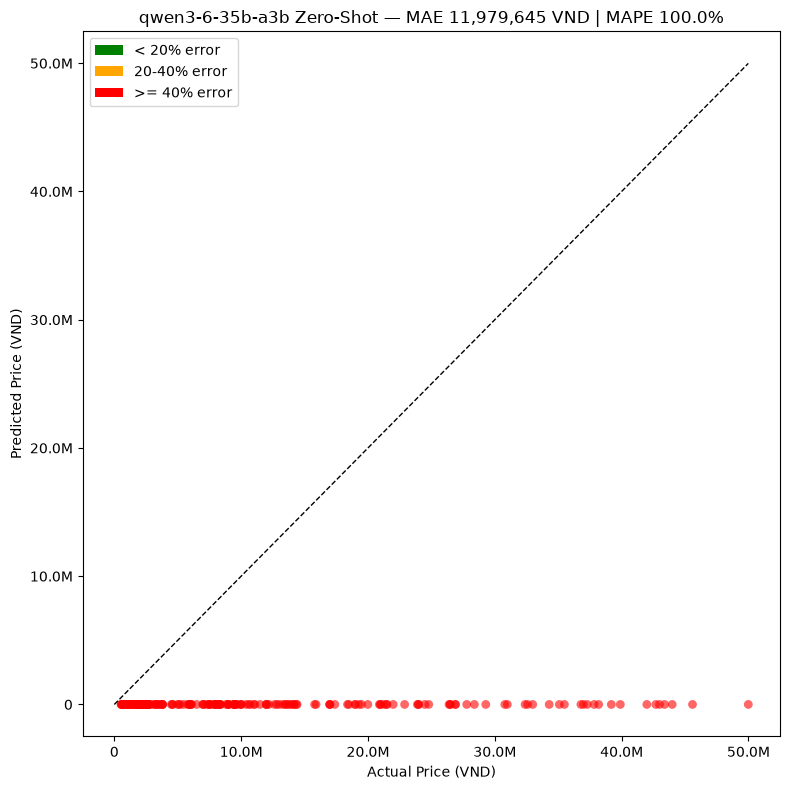

In [6]:
actuals_arr = np.array(truths)
preds_arr = np.array(predictions)
rel_errors = np.abs(preds_arr - actuals_arr) / np.maximum(actuals_arr, 1)

colors = np.where(rel_errors < 0.20, "green", np.where(rel_errors < 0.40, "orange", "red"))

def fmt_vnd(x, _):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.0f}"

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(actuals_arr, preds_arr, c=colors, alpha=0.6, edgecolors="none", s=40)

mn = min(actuals_arr.min(), preds_arr.min())
mx = max(actuals_arr.max(), preds_arr.max())
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_vnd))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_vnd))

legend_elements = [
    Patch(facecolor="green",  label="< 20% error"),
    Patch(facecolor="orange", label="20-40% error"),
    Patch(facecolor="red",    label=">= 40% error"),
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_xlabel("Actual Price (VND)")
ax.set_ylabel("Predicted Price (VND)")
ax.set_title(f"{MODEL} Zero-Shot \u2014 MAE {mae:,.0f} VND | MAPE {mape:.1f}%")
plt.tight_layout()
plt.savefig("llm_zeroshot_scatter.png", dpi=150)
plt.show()

## Compare with Other Models

In [7]:
baselines = [
    ("Constant (mean price)",     9_302_628),
    ("Linear Regression",         7_626_497),
    ("DNN (512h/5L)",             4_495_145),
    ("Random Forest",             4_458_655),
    ("XGBoost",                   3_731_806),
    ("Fine-tuned (pirvn-pricer)", 3_307_045),
    (f"{MODEL} (zero-shot)",      mae),
]

print(f"\n{'Model':<35} {'MAE (VND)':>15}")
print(f"{'\u2500'*35} {'\u2500'*15}")
for name, value in sorted(baselines, key=lambda x: x[1], reverse=True):
    marker = " <--" if "zero-shot" in name else ""
    print(f"{name:<35} {value:>15,.0f}{marker}")


Model                                     MAE (VND)
─────────────────────────────────── ───────────────
qwen3-6-35b-a3b (zero-shot)              11,979,645 <--
Constant (mean price)                     9,302,628
Linear Regression                         7,626,497
DNN (512h/5L)                             4,495,145
Random Forest                             4,458,655
XGBoost                                   3,731,806
Fine-tuned (pirvn-pricer)                 3,307,045
